In [17]:
# from google.colab import drive
# drive.mount('/content/drive')

# ***1️⃣ Import Library***

In [18]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage

# ***2️⃣ Buat Dataset Pelanggan (Sintetis)***
* Annual Income
* Spending Score

In [19]:
np.random.seed(42)

income = np.random.normal(50000, 15000, 200)
spending = np.random.normal(50, 20, 200)

df = pd.DataFrame({
    "Income": income,
    "SpendingScore": spending
})

df.head()

,Income,SpendingScore
0,57450.712295,57.155747
1,47926.035482,61.215691
2,59715.328072,71.661025
3,72845.447846,71.076041
4,46487.699379,22.446613


# ***3️⃣ Scaling (Wajib untuk K-Means)***

In [20]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# ***4️⃣ Tentukan K Optimal (2–10)***

In [21]:
inertia_list = []
silhouette_list = []

K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)

    inertia_list.append(kmeans.inertia_)
    silhouette_list.append(silhouette_score(X_scaled, kmeans.labels_))

# ***5️⃣ Elbow Method (Inertia)***

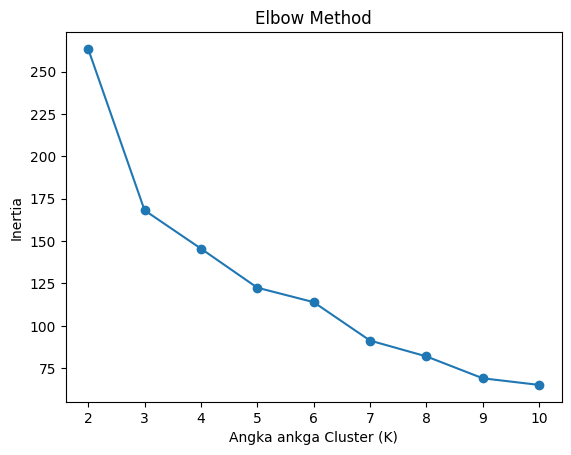

In [22]:
plt.figure()
plt.plot(K_range, inertia_list, marker='o')
plt.title("Elbow Method")
plt.xlabel("Angka ankga Cluster (K)")
plt.ylabel("Inertia")
plt.show()

# ***6️⃣ Silhouette Score***

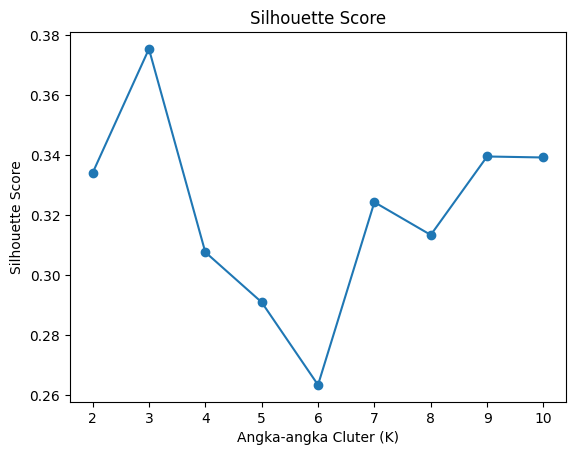

In [23]:
plt.figure()
plt.plot(K_range, silhouette_list, marker='o')
plt.title("Silhouette Score")
plt.xlabel("Angka-angka Cluter (K)")
plt.ylabel("Silhouette Score")
plt.show()

# ***7️⃣ Final K-Means (K=3)***

In [24]:
kmeans = KMeans(n_clusters=3, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

df.head()

,Income,SpendingScore,Cluster
0,57450.712295,57.155747,2
1,47926.035482,61.215691,1
2,59715.328072,71.661025,1
3,72845.447846,71.076041,2
4,46487.699379,22.446613,0


**Visualisasi Cluster**

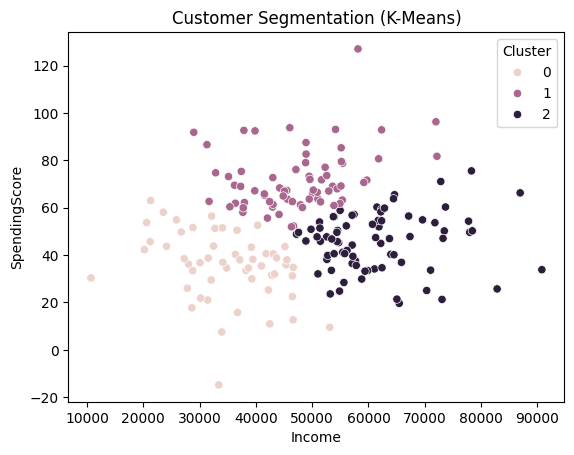

In [25]:
plt.figure()
sns.scatterplot(data=df, x="Income", y="SpendingScore", hue="Cluster")
plt.title("Customer Segmentation (K-Means)")
plt.show()

# ***8️⃣ Profil Tiap Cluster***

In [26]:
cluster_profile = df.groupby("Cluster").mean()
print(cluster_profile)

               Income  SpendingScore
Cluster                             
0        35011.523607      35.553274
1        47344.135589      71.639600
2        61463.014105      45.669479


# Beri Nama Segmen

---



Misalnya berdasarkan rata-rata:

Income tinggi + Spending tinggi → "High Value"

Income rendah + Spending rendah → "Budget"

Income tinggi + Spending rendah → "Saver"

In [27]:
cluster_names = {
    0: "High Value",
    1: "Budget",
    2: "Potential"
}

df["Segment"] = df["Cluster"].map(cluster_names)

# ***9️⃣ Hierarchical Clustering + Dendrogram***

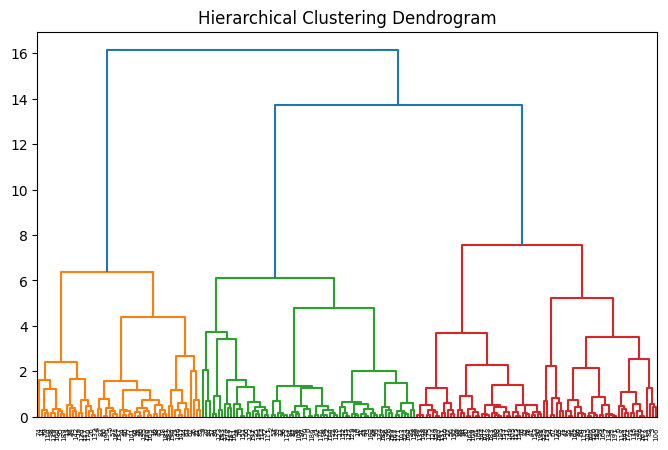

In [28]:
linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(8,5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()

# ***3 Rekomendasi Bisnis***

---



1. High Value
→ Berikan loyalty program & premium offers.

2. Budget Segment
→ Fokus pada diskon & promo bundling.

3. Potential Segment
→ Edukasi produk dan upselling campaign.

# ***Kesimpulan***

---



1. K optimal berdasarkan elbow & silhouette adalah sekitar 3.

2. K-Means efektif untuk segmentasi pelanggan berbasis income & spending.

3. Hierarchical membantu memahami struktur hubungan antar cluster.

In [31]:
import os
os.chdir("/content/drive/MyDrive/ml-practicum")
print(os.getcwd())

/content/drive/MyDrive/ml-practicum


In [32]:
!git pull origin main --rebase
!mkdir -p pertemuan-07
!git add .
!git commit -m "Add pertemuan 07 - Clustering (K-Means & Hierarchical)"
!git push origin main

NameError: name 'run' is not defined